In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
DATA_DIR = Path.cwd().parent/'data'

In [3]:
results = pd.read_csv(DATA_DIR/'results.csv')
results.head(10)

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1
5,6,18,6,3,8,13,6,6,6,3.0,57,\N,\N,50,14,1:29.639,212.974,11
6,7,18,7,5,14,17,7,7,7,2.0,55,\N,\N,54,8,1:29.534,213.224,5
7,8,18,8,6,1,15,8,8,8,1.0,53,\N,\N,20,4,1:27.903,217.180,5
8,9,18,9,2,4,2,\N,R,9,0.0,47,\N,\N,15,9,1:28.753,215.100,4
9,10,18,10,7,12,18,\N,R,10,0.0,43,\N,\N,23,13,1:29.558,213.166,3


In [4]:
results.dtypes

resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number              object
grid                 int64
position            object
positionText        object
positionOrder        int64
points             float64
laps                 int64
time                object
milliseconds        object
fastestLap          object
rank                object
fastestLapTime      object
fastestLapSpeed     object
statusId             int64
dtype: object

In [5]:
results.isna().sum().sum()

np.int64(0)

In [6]:
results['grid'].value_counts()

grid
0     1638
1     1136
7     1135
5     1132
11    1132
9     1132
4     1132
3     1130
10    1130
8     1129
12    1127
13    1125
6     1125
2     1125
14    1120
15    1113
16    1100
17    1089
18    1050
19    1031
20     975
21     697
22     656
23     453
24     429
25     301
26     248
27      46
28      30
29      25
30      19
31      18
32      17
33      13
34       1
Name: count, dtype: int64

In [7]:
results['position'].value_counts()

position
\N    10953
3      1135
4      1135
2      1133
5      1131
1      1128
6      1124
7      1104
8      1076
9      1038
10      978
11      901
12      800
13      713
14      605
15      528
16      432
17      336
18      223
19      141
20       72
21       34
22       19
23        8
24        3
25        1
26        1
27        1
28        1
29        1
30        1
31        1
32        1
33        1
Name: count, dtype: int64

In [8]:
df_nopitstart = results.loc[results['grid'] != 0].copy()

Removing rows, where drivers started race from pitlane

In [9]:
results.head(10)

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1
5,6,18,6,3,8,13,6,6,6,3.0,57,\N,\N,50,14,1:29.639,212.974,11
6,7,18,7,5,14,17,7,7,7,2.0,55,\N,\N,54,8,1:29.534,213.224,5
7,8,18,8,6,1,15,8,8,8,1.0,53,\N,\N,20,4,1:27.903,217.180,5
8,9,18,9,2,4,2,\N,R,9,0.0,47,\N,\N,15,9,1:28.753,215.100,4
9,10,18,10,7,12,18,\N,R,10,0.0,43,\N,\N,23,13,1:29.558,213.166,3


In [10]:
df_nopitstart['positions_gained'] = df_nopitstart['grid'] - df_nopitstart['positionOrder']
df_nopitstart

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,positions_gained
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,0
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1,3
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1,4
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1,7
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1,-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26754,26760,1144,825,210,20,14,16,16,16,0.0,57,\N,\N,57,1,1:25.637,222.002,11,-2
26755,26761,1144,859,215,30,12,17,17,17,0.0,55,\N,\N,52,12,1:28.751,214.212,5,-5
26756,26762,1144,822,15,77,9,\N,R,18,0.0,30,\N,\N,14,19,1:29.482,212.462,130,-9
26757,26763,1144,861,3,43,20,\N,R,19,0.0,26,\N,\N,5,17,1:29.411,212.631,5,1


In [11]:
avg_positions_gained = df_nopitstart.groupby('driverId')['positions_gained'].mean().reset_index()
avg_positions_gained

,driverId,positions_gained
0,1,-0.695775
1,2,0.614130
2,3,-1.349515
3,4,0.126551
4,5,0.455357
...,...,...
787,858,0.542857
788,859,0.545455
789,860,2.333333
790,861,2.000000


In [12]:
avg_positions_gained = avg_positions_gained.sort_values(by='positions_gained', ascending=False)
avg_positions_gained

,driverId,positions_gained
524,591,23.0
459,515,19.0
641,709,17.0
436,489,17.0
697,767,17.0
...,...,...
284,315,-14.0
568,635,-15.0
471,527,-15.0
481,537,-16.8


In [13]:
race_counts = df_nopitstart.groupby('driverId').size().reset_index(name='num_races')
race_counts

,driverId,num_races
0,1,355
1,2,184
2,3,206
3,4,403
4,5,112
...,...,...
787,858,35
788,859,11
789,860,3
790,861,8


In [14]:
driver_stats = avg_positions_gained.merge(race_counts, on='driverId')
driver_stats

,driverId,positions_gained,num_races
0,591,23.0,1
1,515,19.0,1
2,709,17.0,2
3,489,17.0,1
4,767,17.0,1
...,...,...,...
787,315,-14.0,1
788,635,-15.0,1
789,527,-15.0,4
790,537,-16.8,5


In [15]:
driver_stats = driver_stats.loc[driver_stats['num_races'] > 100, :]
driver_stats

,driverId,positions_gained,num_races
325,63,2.745455,110
336,200,2.613208,106
367,112,2.137615,109
371,50,2.084112,107
396,84,1.860759,158
...,...,...,...
726,119,-3.447471,257
733,207,-3.890625,128
743,95,-4.484043,188
745,77,-4.542857,210


In [16]:
drivers = pd.read_csv(DATA_DIR/'processed_data'/'clean_drivers.csv')

final_stats = driver_stats.merge(drivers[['driverId','full_name']], on='driverId', how='left')
final_stats

,driverId,positions_gained,num_races,full_name
0,63,2.745455,110,Mika Salo
1,200,2.613208,106,Jochen Mass
2,112,2.137615,109,Philippe Alliot
3,50,2.084112,107,Jos Verstappen
4,84,1.860759,158,Martin Brundle
...,...,...,...,...
76,119,-3.447471,257,Riccardo Patrese
77,207,-3.890625,128,Mario Andretti
78,95,-4.484043,188,Nigel Mansell
79,77,-4.542857,210,Gerhard Berger


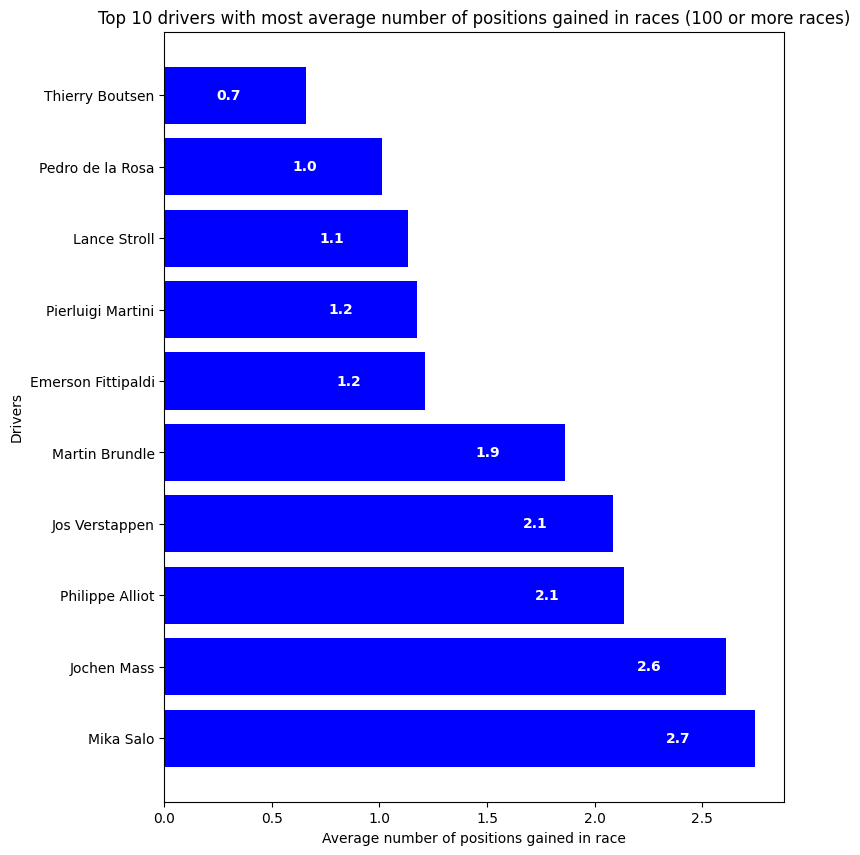

In [17]:
top10_positions_gained = final_stats.head(10)

fig, ax = plt.subplots(figsize=(8,10))
bars = ax.barh(top10_positions_gained['full_name'], top10_positions_gained['positions_gained'], color='blue')
ax.set_xlabel("Average number of positions gained in race")
ax.set_ylabel("Drivers")
ax.set_title("Top 10 drivers with most average number of positions gained in races (100 or more races)")
for bar in bars:
    width = bar.get_width()
    plt.text(width - 0.3, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}', va='center', ha='right', color='white', fontweight='bold')

plt.show()